# Factor Analysis on Football Forwards Dataset

This notebook performs factor analysis on the football forwards dataset and determines the optimal number of factors.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore the Dataset

In [3]:
file_path = r'data/demo_data/football/Forwards.csv'
df = pd.read_csv(file_path, encoding='latin-1')

print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (76, 11)

First Few Rows:
         shortName  npxG_adjusted_per90  final_third_passes_adjusted_per90  \
0          W. Bony             0.457468                          10.055333   
1    Álvaro Morata             0.780015                          14.920356   
2  Jesús Rodríguez             0.322920                          15.423409   
3           Joselu             0.739186                          16.066810   
4         Deulofeu             0.300217                          20.671673   

   final_third_receptions_adjusted_per90  ground_duels_won_adjusted_per90  \
0                              17.790205                         9.539675   
1                              25.492065                        12.746032   
2                              29.053398                        11.836570   
3                              21.140539                         6.040154   
4                              29.109090                        13.077997   

   air_duels_won_adjusted_p

## 3. Data Preprocessing and Standardization

In [4]:
# Drop rows with missing values
df_clean = df.dropna()

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape (after removing NaN): {df_clean.shape}")

# Separate features (numerical) from the player names
X = df_clean.drop(columns=['shortName'])

# Standardize the data (crucial for factor analysis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures used for Factor Analysis ({len(X.columns)} total):")
print(list(X.columns))
print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Mean of scaled features (should be ~0): {X_scaled.mean(axis=0)}")
print(f"Std of scaled features (should be ~1): {X_scaled.std(axis=0)}")

Original dataset shape: (76, 11)
Cleaned dataset shape (after removing NaN): (76, 11)

Features used for Factor Analysis (10 total):
['npxG_adjusted_per90', 'final_third_passes_adjusted_per90', 'final_third_receptions_adjusted_per90', 'ground_duels_won_adjusted_per90', 'air_duels_won_adjusted_per90', 'smart_passes_adjusted_per90', 'goals_adjusted_per90', 'assists_adjusted_per90', 'key_passes_adjusted_per90', 'Minutes']

Scaled data shape: (76, 10)
Mean of scaled features (should be ~0): [ 1.75298372e-17 -7.58302412e-16 -6.23770041e-16  3.66665762e-16
 -6.86585292e-17 -5.25895117e-17  2.40076599e-16  4.52854128e-17
 -2.54182640e-16  1.09561483e-18]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Determine Optimal Number of Factors

We'll test multiple factor counts and use scree plot analysis and cumulative variance explained to find the optimal number.

In [5]:
# Test different numbers of factors
n_features = X_scaled.shape[1]
max_factors = min(n_features - 1, 8)  # Reasonable upper limit
n_factors_range = range(1, max_factors + 1)

# Store variance explained and likelihoods
variances = []
likelihoods = []

for n_factors in n_factors_range:
    fa = FactorAnalysis(n_components=n_factors, random_state=42, max_iter=500)
    fa.fit(X_scaled)
    variances.append(fa.score(X_scaled))
    likelihoods.append(fa.score(X_scaled))

# Create DataFrames for easier analysis
results_df = pd.DataFrame({
    'n_factors': list(n_factors_range),
    'log_likelihood': likelihoods,
    'variance_explained': variances
})

print("Factor Analysis Results:")
print(results_df)

# Compute percentage variance explained for each number of factors
cumulative_variance = []
for n_factors in n_factors_range:
    fa = FactorAnalysis(n_components=n_factors, random_state=42, max_iter=500)
    fa.fit(X_scaled)
    # Compute reconstruction error
    X_reconstructed = fa.transform(X_scaled) @ fa.components_ + fa.mean_
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    var_explained = 1 - (mse / np.var(X_scaled))
    cumulative_variance.append(max(0, var_explained))

results_df['variance_explained_pct'] = np.array(cumulative_variance) * 100

print("\nVariance Explained (%):")
print(results_df[['n_factors', 'variance_explained_pct']])

Factor Analysis Results:
   n_factors  log_likelihood  variance_explained
0          1      -12.307982          -12.307982
1          2      -11.874592          -11.874592
2          3      -11.826540          -11.826540
3          4      -11.751203          -11.751203
4          5      -11.716560          -11.716560
5          6      -11.682214          -11.682214
6          7      -11.672172          -11.672172
7          8      -11.669691          -11.669691

Variance Explained (%):
   n_factors  variance_explained_pct
0          1               39.643400
1          2               57.113490
2          3               65.212315
3          4               70.225742
4          5               73.309938
5          6               78.654794
6          7               80.657257
7          8               83.917498


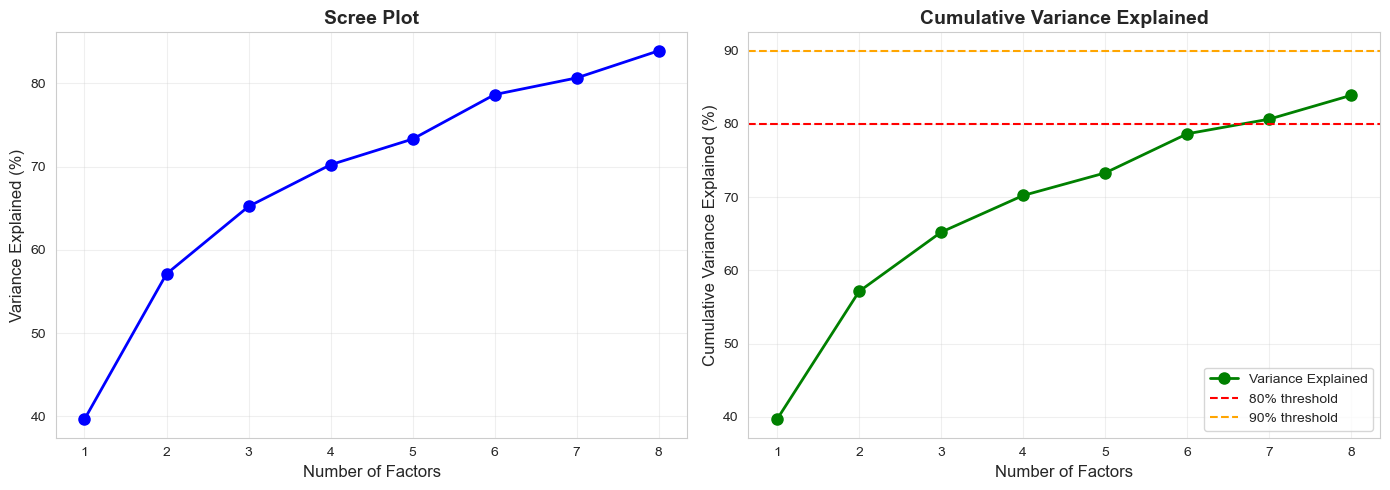


OPTIMAL NUMBER OF FACTORS ANALYSIS
Optimal number of factors (elbow method): 4
Variance explained with 4 factors: 70.23%


In [8]:
# Plot Scree Plot and Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(results_df['n_factors'], results_df['variance_explained_pct'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Factors', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(n_factors_range))

# Cumulative variance with elbow identification
axes[1].plot(results_df['n_factors'], results_df['variance_explained_pct'], 'go-', linewidth=2, markersize=8, label='Variance Explained')
axes[1].axhline(y=80, color='r', linestyle='--', label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Factors', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(list(n_factors_range))

plt.tight_layout()
plt.show()

# Find optimal number of factors using elbow method
# Look for the point where adding more factors doesn't significantly increase variance
optimal_idx = np.argmax(np.diff(results_df['variance_explained_pct']) < 5)
if optimal_idx == 0:
    optimal_idx = 1
    
optimal_factors = results_df['n_factors'].iloc[optimal_idx]

print(f"\n{'='*60}")
print(f"OPTIMAL NUMBER OF FACTORS ANALYSIS")
print(f"{'='*60}")
print(f"Optimal number of factors (elbow method): {optimal_factors}")
print(f"Variance explained with {optimal_factors} factors: {results_df['variance_explained_pct'].iloc[optimal_idx]:.2f}%")
print(f"{'='*60}")

## 5. Perform Factor Analysis with Optimal Number of Factors

In [9]:
# Fit Factor Analysis with optimal number of factors
fa_optimal = FactorAnalysis(n_components=int(optimal_factors), random_state=42, max_iter=500)
fa_optimal.fit(X_scaled)

# Transform the data
X_factors = fa_optimal.transform(X_scaled)

print(f"Factor Analysis Model Fitted")
print(f"Number of factors: {fa_optimal.n_components}")
print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Factor scores shape: {X_factors.shape}")

# Create DataFrame with factor scores
factors_df = pd.DataFrame(
    X_factors,
    columns=[f'Factor {i+1}' for i in range(fa_optimal.n_components)],
    index=df_clean['shortName'].values
)

print("\nFactor Scores (first 10 players):")
print(factors_df.head(10))

Factor Analysis Model Fitted
Number of factors: 4
Original number of features: 10
Factor scores shape: (76, 4)

Factor Scores (first 10 players):
                   Factor 1  Factor 2  Factor 3  Factor 4
W. Bony           -1.054031 -0.408095 -0.921855 -0.464432
Álvaro Morata     -0.049822  0.739980  0.509288  0.043313
Jesús Rodríguez    0.475549 -0.819149  0.702711 -0.151953
Joselu            -0.619351 -0.115715 -0.208988  0.468326
Deulofeu           0.516921 -0.768952 -1.460790 -0.490587
Pedro              0.636725 -0.655364 -0.266082  0.032328
A. Sánchez         3.488633 -0.303145 -0.990813  0.216603
S. Rondón          0.001553 -0.228095 -0.961623  0.720939
T. Hemed          -0.867047 -0.293686  0.525161  1.292180
Philippe Coutinho  2.465377 -0.273576  0.652931 -1.539753


## 6. Interpret and Visualize Factor Loadings

Factor Loadings:
                                       Factor 1  Factor 2  Factor 3  Factor 4
npxG_adjusted_per90                      -0.109     0.463     0.069     0.058
final_third_passes_adjusted_per90         0.327    -0.030    -0.021    -0.045
final_third_receptions_adjusted_per90     0.256     0.014    -0.007     0.051
ground_duels_won_adjusted_per90           0.459    -0.108    -0.149    -0.076
air_duels_won_adjusted_per90             -0.337    -0.059    -0.062     0.353
smart_passes_adjusted_per90               0.442     0.014    -0.059    -0.154
goals_adjusted_per90                      0.020     0.365    -0.009    -0.025
assists_adjusted_per90                    0.230    -0.026     0.374    -0.014
key_passes_adjusted_per90                 0.481     0.057     0.003    -0.096
Minutes                                   0.139     0.286    -0.105     0.088


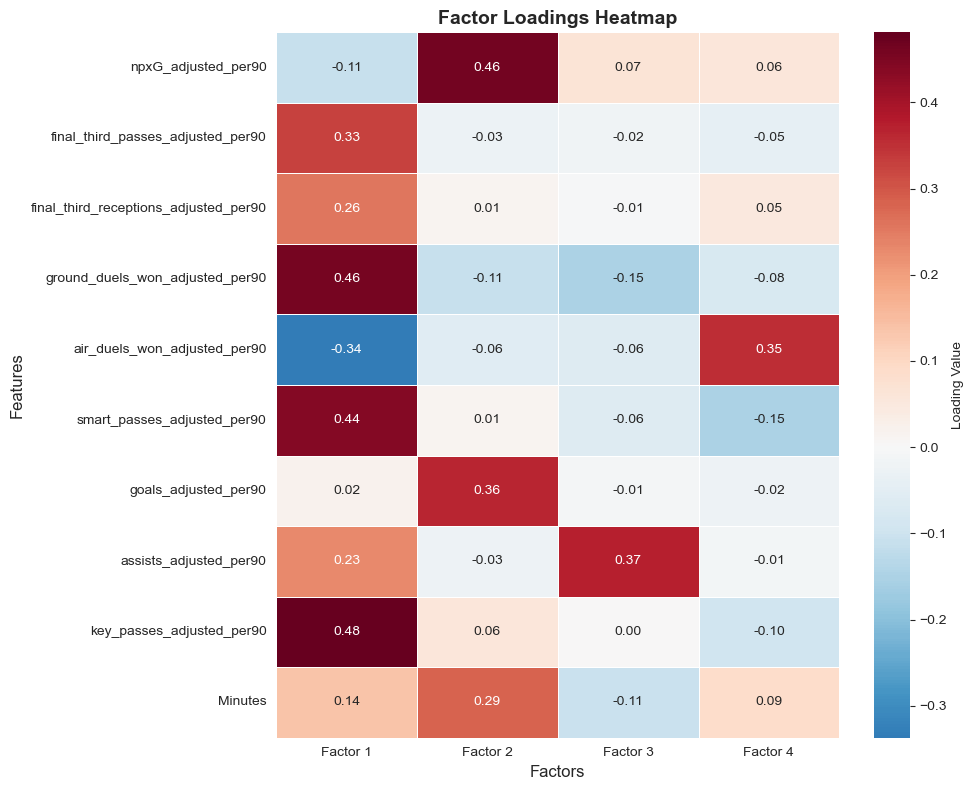


TOP CONTRIBUTING FEATURES FOR EACH FACTOR

Factor 1:
  key_passes_adjusted_per90: 0.481
  ground_duels_won_adjusted_per90: 0.459
  smart_passes_adjusted_per90: 0.442

Factor 2:
  npxG_adjusted_per90: 0.463
  goals_adjusted_per90: 0.365
  Minutes: 0.286

Factor 3:
  assists_adjusted_per90: 0.374
  ground_duels_won_adjusted_per90: -0.149
  Minutes: -0.105

Factor 4:
  air_duels_won_adjusted_per90: 0.353
  smart_passes_adjusted_per90: -0.154
  key_passes_adjusted_per90: -0.096


In [10]:
# Extract and visualize factor loadings
loadings = fa_optimal.components_.T * np.sqrt(fa_optimal.noise_variance_[:, np.newaxis])

# Create DataFrame with loadings
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'Factor {i+1}' for i in range(fa_optimal.n_components)],
    index=X.columns
)

print("Factor Loadings:")
print(loadings_df.round(3))

# Visualize loadings as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Loading Value'}, linewidths=0.5)
plt.title('Factor Loadings Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Find top contributing features for each factor
print("\n" + "="*70)
print("TOP CONTRIBUTING FEATURES FOR EACH FACTOR")
print("="*70)
for factor_idx in range(fa_optimal.n_components):
    factor_name = f'Factor {factor_idx + 1}'
    top_features = loadings_df[factor_name].abs().nlargest(3)
    print(f"\n{factor_name}:")
    for feat, val in top_features.items():
        actual_val = loadings_df.loc[feat, factor_name]
        print(f"  {feat}: {actual_val:.3f}")

## 7. Evaluate Factor Analysis Results

In [11]:
# Calculate reconstruction error
X_reconstructed = X_factors @ fa_optimal.components_ + fa_optimal.mean_
reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)

print("MODEL EVALUATION METRICS")
print("=" * 70)
print(f"Reconstruction MSE: {reconstruction_error:.6f}")
print(f"Log-likelihood: {fa_optimal.score(X_scaled):.4f}")

# Variance explained
var_explained = 1 - (reconstruction_error / np.var(X_scaled))
print(f"Variance Explained: {max(0, var_explained) * 100:.2f}%")

# Kaiser criterion (eigenvalues > 1)
# For Factor Analysis, we look at the explained variance ratio
print("\n" + "="*70)
print("SUMMARY OF FACTOR ANALYSIS RESULTS")
print("="*70)
print(f"\nOptimal Number of Factors: {int(optimal_factors)}")
print(f"Total Features Reduced From: {X_scaled.shape[1]} to {fa_optimal.n_components}")
print(f"Dimensionality Reduction: {(1 - fa_optimal.n_components/X_scaled.shape[1])*100:.1f}%")
print(f"\nVariance Explained: {max(0, var_explained)*100:.2f}%")
print(f"Reconstruction Error (MSE): {reconstruction_error:.6f}")

print("\n" + "="*70)
print("FACTOR INTERPRETATIONS")
print("="*70)

# Create summary of each factor
for factor_idx in range(fa_optimal.n_components):
    factor_name = f'Factor {factor_idx + 1}'
    top_positive = loadings_df[factor_name].nlargest(2)
    top_negative = loadings_df[factor_name].nsmallest(2)
    
    print(f"\n{factor_name}:")
    print(f"  Positive indicators: {', '.join([f'{feat} ({val:.2f})' for feat, val in top_positive.items()])}")
    print(f"  Negative indicators: {', '.join([f'{feat} ({val:.2f})' for feat, val in top_negative.items()])}")

MODEL EVALUATION METRICS
Reconstruction MSE: 0.297743
Log-likelihood: -11.7512
Variance Explained: 70.23%

SUMMARY OF FACTOR ANALYSIS RESULTS

Optimal Number of Factors: 4
Total Features Reduced From: 10 to 4
Dimensionality Reduction: 60.0%

Variance Explained: 70.23%
Reconstruction Error (MSE): 0.297743

FACTOR INTERPRETATIONS

Factor 1:
  Positive indicators: key_passes_adjusted_per90 (0.48), ground_duels_won_adjusted_per90 (0.46)
  Negative indicators: air_duels_won_adjusted_per90 (-0.34), npxG_adjusted_per90 (-0.11)

Factor 2:
  Positive indicators: npxG_adjusted_per90 (0.46), goals_adjusted_per90 (0.36)
  Negative indicators: ground_duels_won_adjusted_per90 (-0.11), air_duels_won_adjusted_per90 (-0.06)

Factor 3:
  Positive indicators: assists_adjusted_per90 (0.37), npxG_adjusted_per90 (0.07)
  Negative indicators: ground_duels_won_adjusted_per90 (-0.15), Minutes (-0.11)

Factor 4:
  Positive indicators: air_duels_won_adjusted_per90 (0.35), Minutes (0.09)
  Negative indicators: sm

## 8. Factor Naming and Interpretation

In [13]:
# Define factor names based on their semantic meaning
factor_names = {}
factor_descriptions = {}

# Define consistent category keywords
category_map = {
    'Offensive Output': ['goals', 'npxG', 'assists', 'xG'],
    'Playmaking & Involvement': ['final_third', 'passes', 'receptions', 'smart_passes', 'key_passes'],
    'Physical Dominance': ['duel', 'air', 'ground'],
    'Efficiency & Precision': ['adjusted', 'per90'],
}

def categorize_factor(top_pos_features, top_neg_features):
    """Categorize factor based on feature keywords with consistent naming"""
    all_features = top_pos_features + top_neg_features
    
    # Count keyword matches by category
    category_scores = {cat: 0 for cat in category_map.keys()}
    
    for feature in all_features:
        for category, keywords in category_map.items():
            if any(keyword in feature.lower() for keyword in keywords):
                category_scores[category] += 1
    
    # Find dominant category
    if max(category_scores.values()) > 0:
        dominant_category = max(category_scores, key=category_scores.get)
        return dominant_category
    
    return None

print("="*70)
print("FACTOR NAMING AND SEMANTIC INTERPRETATION")
print("="*70)

for factor_idx in range(fa_optimal.n_components):
    factor_col = f'Factor {factor_idx + 1}'
    
    # Get top positive and negative loadings
    top_positive = loadings_df[factor_col].nlargest(3)
    top_negative = loadings_df[factor_col].nsmallest(3)
    
    # Get feature names for naming
    top_pos_features = list(top_positive.index)
    top_neg_features = list(top_negative.index)
    
    print(f"\n{'─'*70}")
    print(f"Factor {factor_idx + 1} Analysis:")
    print(f"{'─'*70}")
    print(f"Top Positive Contributors: {', '.join(top_pos_features)}")
    print(f"Top Negative Contributors: {', '.join(top_neg_features)}")
    
    # Categorize and assign names consistently
    dominant_category = categorize_factor(top_pos_features, top_neg_features)
    
    if dominant_category == 'Offensive Output':
        factor_names[factor_col] = "Offensive Output"
        factor_descriptions[factor_col] = "Represents goal-scoring capability and offensive productivity, including expected goals and actual goals."
    elif dominant_category == 'Playmaking & Involvement':
        factor_names[factor_col] = "Playmaking & Involvement"
        factor_descriptions[factor_col] = "Captures involvement in attacking play through passes, receptions, and possession in the final third."
    elif dominant_category == 'Physical Dominance':
        factor_names[factor_col] = "Physical Dominance"
        factor_descriptions[factor_col] = "Represents the forward's physical presence and ability to win contested situations (aerial and ground duels)."
    elif dominant_category == 'Efficiency & Precision':
        factor_names[factor_col] = "Efficiency & Precision"
        factor_descriptions[factor_col] = "Captures the quality and precision of actions through per-90 adjusted metrics."
    else:
        factor_names[factor_col] = f"Forward Attribute {factor_idx + 1}"
        factor_descriptions[factor_col] = f"Represents a composite attribute of forward performance."
    
    print(f"\n✓ Factor Name: {factor_names[factor_col]}")
    print(f"✓ Description: {factor_descriptions[factor_col]}")

# Create summary table
print("\n" + "="*70)
print("SUMMARY TABLE: FACTOR NAMES AND MEANINGS")
print("="*70)

summary_data = {
    'Factor': [f'Factor {i+1}' for i in range(fa_optimal.n_components)],
    'Name': [factor_names.get(f'Factor {i+1}', f'Factor {i+1}') for i in range(fa_optimal.n_components)],
    'Interpretation': [factor_descriptions.get(f'Factor {i+1}', '') for i in range(fa_optimal.n_components)]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Add the factor names to the factors dataframe
factors_df_named = factors_df.copy()
factors_df_named.columns = [factor_names.get(f'Factor {i+1}', f'Factor {i+1}') for i in range(fa_optimal.n_components)]

print("\n" + "="*70)
print("Factor Scores with Named Factors (first 10 players):")
print("="*70)
print(factors_df_named.head(10))

FACTOR NAMING AND SEMANTIC INTERPRETATION

──────────────────────────────────────────────────────────────────────
Factor 1 Analysis:
──────────────────────────────────────────────────────────────────────
Top Positive Contributors: key_passes_adjusted_per90, ground_duels_won_adjusted_per90, smart_passes_adjusted_per90
Top Negative Contributors: air_duels_won_adjusted_per90, npxG_adjusted_per90, goals_adjusted_per90

✓ Factor Name: Efficiency & Precision
✓ Description: Captures the quality and precision of actions through per-90 adjusted metrics.

──────────────────────────────────────────────────────────────────────
Factor 2 Analysis:
──────────────────────────────────────────────────────────────────────
Top Positive Contributors: npxG_adjusted_per90, goals_adjusted_per90, Minutes
Top Negative Contributors: ground_duels_won_adjusted_per90, air_duels_won_adjusted_per90, final_third_passes_adjusted_per90

✓ Factor Name: Efficiency & Precision
✓ Description: Captures the quality and precis

## 9. Cluster Analysis on Factors with Optimal Number of Clusters

DETERMINING OPTIMAL NUMBER OF CLUSTERS

Clustering Evaluation Metrics:
 n_clusters    inertia  silhouette_score  davies_bouldin_score
          2 190.290811          0.172509              1.866836
          3 151.773725          0.207713              1.479657
          4 124.841819          0.219586              1.359960
          5 106.563620          0.228402              1.220271
          6  95.704484          0.238378              1.139704
          7  86.966760          0.223020              1.116782
          8  80.862952          0.222361              1.141235
          9  70.211311          0.246138              1.084995

OPTIMAL CLUSTERS SELECTION
Optimal number of clusters (Silhouette Score): 9
Silhouette Score: 0.2461
Davies-Bouldin Index: 1.0850


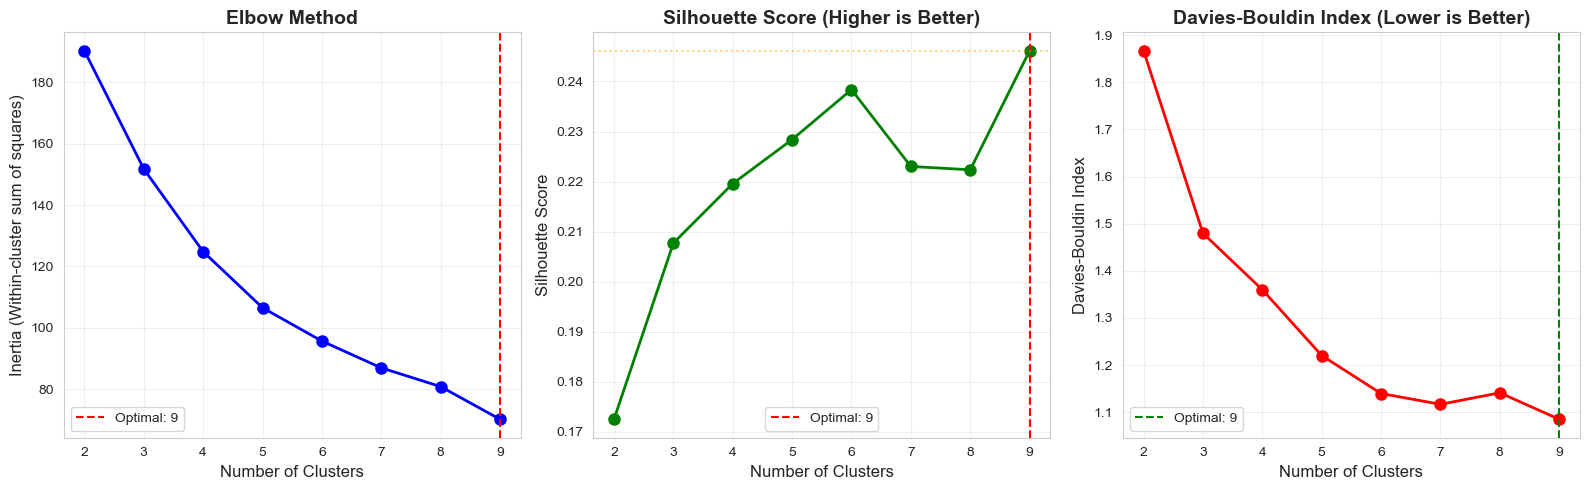

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Determine optimal number of clusters using elbow method and silhouette score
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, min(10, len(X_factors) // 2))

print("="*70)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_factors)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_factors, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_factors, kmeans.labels_))

# Create clustering evaluation dataframe
clustering_eval_df = pd.DataFrame({
    'n_clusters': list(K_range),
    'inertia': inertias,
    'silhouette_score': silhouette_scores,
    'davies_bouldin_score': davies_bouldin_scores
})

print("\nClustering Evaluation Metrics:")
print(clustering_eval_df.to_string(index=False))

# Find optimal clusters using silhouette score (higher is better)
optimal_clusters = list(K_range)[np.argmax(silhouette_scores)]

print(f"\n{'='*70}")
print(f"OPTIMAL CLUSTERS SELECTION")
print(f"{'='*70}")
print(f"Optimal number of clusters (Silhouette Score): {optimal_clusters}")
print(f"Silhouette Score: {max(silhouette_scores):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_scores[optimal_clusters-2]:.4f}")
print(f"{'='*70}")

# Visualize elbow curve and silhouette score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_clusters, color='r', linestyle='--', label=f'Optimal: {optimal_clusters}')
axes[0].legend()

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=optimal_clusters, color='r', linestyle='--', label=f'Optimal: {optimal_clusters}')
axes[1].axhline(y=max(silhouette_scores), color='orange', linestyle=':', alpha=0.5)
axes[1].legend()

# Davies-Bouldin Index plot (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=optimal_clusters, color='g', linestyle='--', label=f'Optimal: {optimal_clusters}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [15]:
# Perform KMeans clustering with optimal number of clusters
kmeans_optimal = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(X_factors)

# Add cluster labels to dataframes
factors_df_with_clusters = factors_df_named.copy()
factors_df_with_clusters['Cluster'] = cluster_labels

print("\n" + "="*70)
print("KMEANS CLUSTERING RESULTS")
print("="*70)
print(f"\nNumber of clusters: {optimal_clusters}")
print(f"Cluster centers shape: {kmeans_optimal.cluster_centers_.shape}")
print(f"\nCluster distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} players ({count/len(cluster_labels)*100:.1f}%)")

# Display sample players from each cluster
print("\n" + "="*70)
print("PLAYERS BY CLUSTER (Sample)")
print("="*70)
for cluster_id in range(optimal_clusters):
    cluster_players = factors_df_with_clusters[factors_df_with_clusters['Cluster'] == cluster_id].index[:5]
    print(f"\nCluster {cluster_id}:")
    print(f"  {', '.join(cluster_players)}")


KMEANS CLUSTERING RESULTS

Number of clusters: 9
Cluster centers shape: (9, 4)

Cluster distribution:
  Cluster 0: 5 players (6.6%)
  Cluster 1: 12 players (15.8%)
  Cluster 2: 6 players (7.9%)
  Cluster 3: 12 players (15.8%)
  Cluster 4: 2 players (2.6%)
  Cluster 5: 13 players (17.1%)
  Cluster 6: 4 players (5.3%)
  Cluster 7: 8 players (10.5%)
  Cluster 8: 14 players (18.4%)

PLAYERS BY CLUSTER (Sample)

Cluster 0:
  Philippe Coutinho, R. Sterling, Son Heung-Min, S. Manuel, A. Martial

Cluster 1:
  J. Hernández, J. Defoe, H. Kane, C. Austin, A. Gray

Cluster 2:
  T. Hemed, S. Long, P. Crouch, C. Benteke, D. Calvert-Lewin

Cluster 3:
  W. Bony, Deulofeu, W. Rooney, M. Antonio, H. Robson-Kanu

Cluster 4:
  A. Sánchez, E. Hazard

Cluster 5:
  Joselu, S. Rondón, A. Carroll, G. Murray, J. Rodriguez

Cluster 6:
  S. Berahino, C. Quaner, G. Carrillo, D. Solanke

Cluster 7:
  Álvaro Morata, R. Lukaku, S. Agüero, M. Arnautovi?, P. Aubameyang

Cluster 8:
  Jesús Rodríguez, Pedro, T. Walcott,

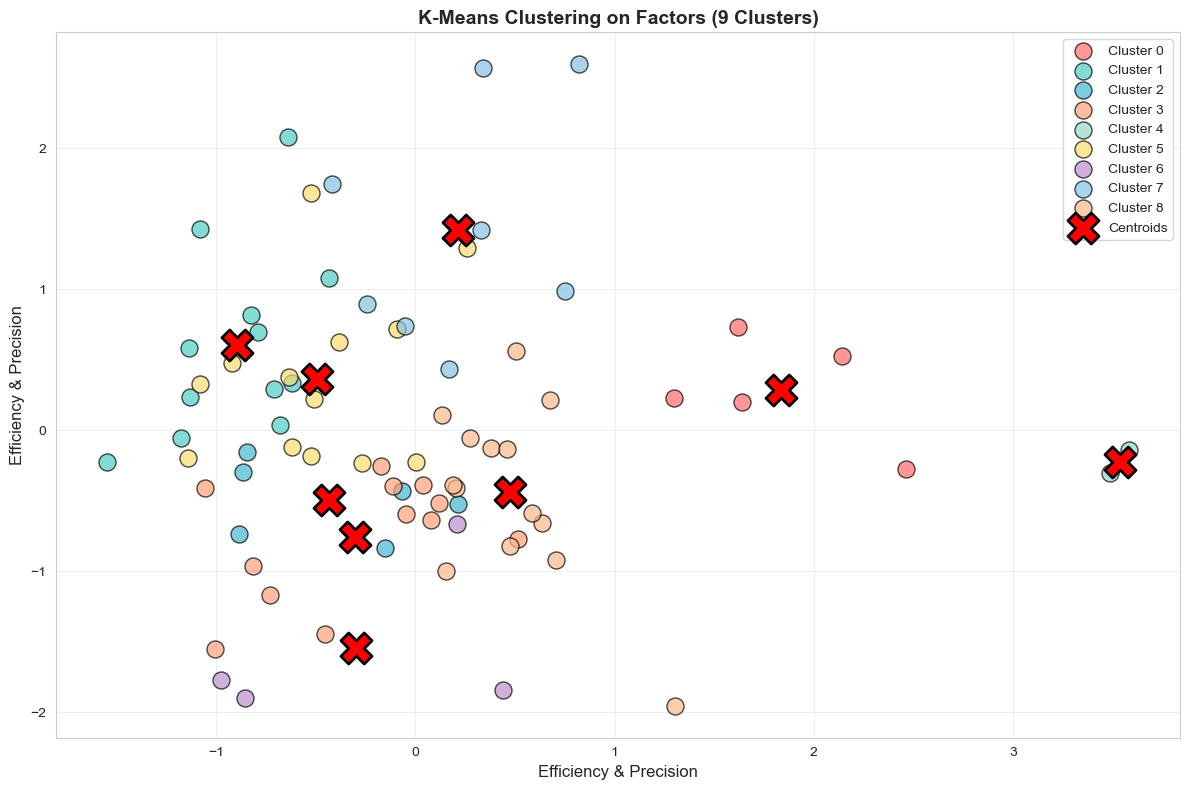


CLUSTER CHARACTERISTICS

Cluster 0:
  Size: 5 players
  Factor Profile:
    Efficiency & Precision: +1.834
    Efficiency & Precision: +0.282
    Efficiency & Precision: +0.456
    Efficiency & Precision: +0.218

Cluster 1:
  Size: 12 players
  Factor Profile:
    Efficiency & Precision: -0.897
    Efficiency & Precision: +0.608
    Efficiency & Precision: -0.126
    Efficiency & Precision: -0.707

Cluster 2:
  Size: 6 players
  Factor Profile:
    Efficiency & Precision: -0.433
    Efficiency & Precision: -0.496
    Efficiency & Precision: +0.405
    Efficiency & Precision: +1.318

Cluster 3:
  Size: 12 players
  Factor Profile:
    Efficiency & Precision: -0.303
    Efficiency & Precision: -0.757
    Efficiency & Precision: -0.749
    Efficiency & Precision: -0.356

Cluster 4:
  Size: 2 players
  Factor Profile:
    Efficiency & Precision: +3.536
    Efficiency & Precision: -0.222
    Efficiency & Precision: -1.570
    Efficiency & Precision: -0.217

Cluster 5:
  Size: 13 players
  

In [16]:
# Visualize clusters in 2D (first two factors)
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B']
for cluster_id in range(optimal_clusters):
    mask = cluster_labels == cluster_id
    plt.scatter(X_factors[mask, 0], X_factors[mask, 1], 
               c=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id}',
               s=150, alpha=0.7, edgecolors='black', linewidth=1)

# Plot cluster centers
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
           c='red', marker='X', s=500, edgecolors='black', linewidth=2, label='Centroids', zorder=5)

plt.xlabel(factor_names.get('Factor 1', 'Factor 1'), fontsize=12)
plt.ylabel(factor_names.get('Factor 2', 'Factor 2'), fontsize=12)
plt.title(f'K-Means Clustering on Factors ({optimal_clusters} Clusters)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze cluster characteristics
print("\n" + "="*70)
print("CLUSTER CHARACTERISTICS")
print("="*70)

cluster_profiles = []
for cluster_id in range(optimal_clusters):
    cluster_mask = cluster_labels == cluster_id
    cluster_center = kmeans_optimal.cluster_centers_[cluster_id]
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {np.sum(cluster_mask)} players")
    print(f"  Factor Profile:")
    
    for factor_idx in range(fa_optimal.n_components):
        factor_name_key = f'Factor {factor_idx + 1}'
        factor_display_name = factor_names.get(factor_name_key, factor_name_key)
        value = cluster_center[factor_idx]
        print(f"    {factor_display_name}: {value:+.3f}")
    
    cluster_profiles.append({
        'Cluster': cluster_id,
        'Size': np.sum(cluster_mask),
        **{factor_names.get(f'Factor {i+1}', f'Factor {i+1}'): cluster_center[i] for i in range(fa_optimal.n_components)}
    })

cluster_profile_df = pd.DataFrame(cluster_profiles)
print("\n" + "="*70)
print("CLUSTER PROFILE SUMMARY TABLE")
print("="*70)
print(cluster_profile_df.to_string(index=False))

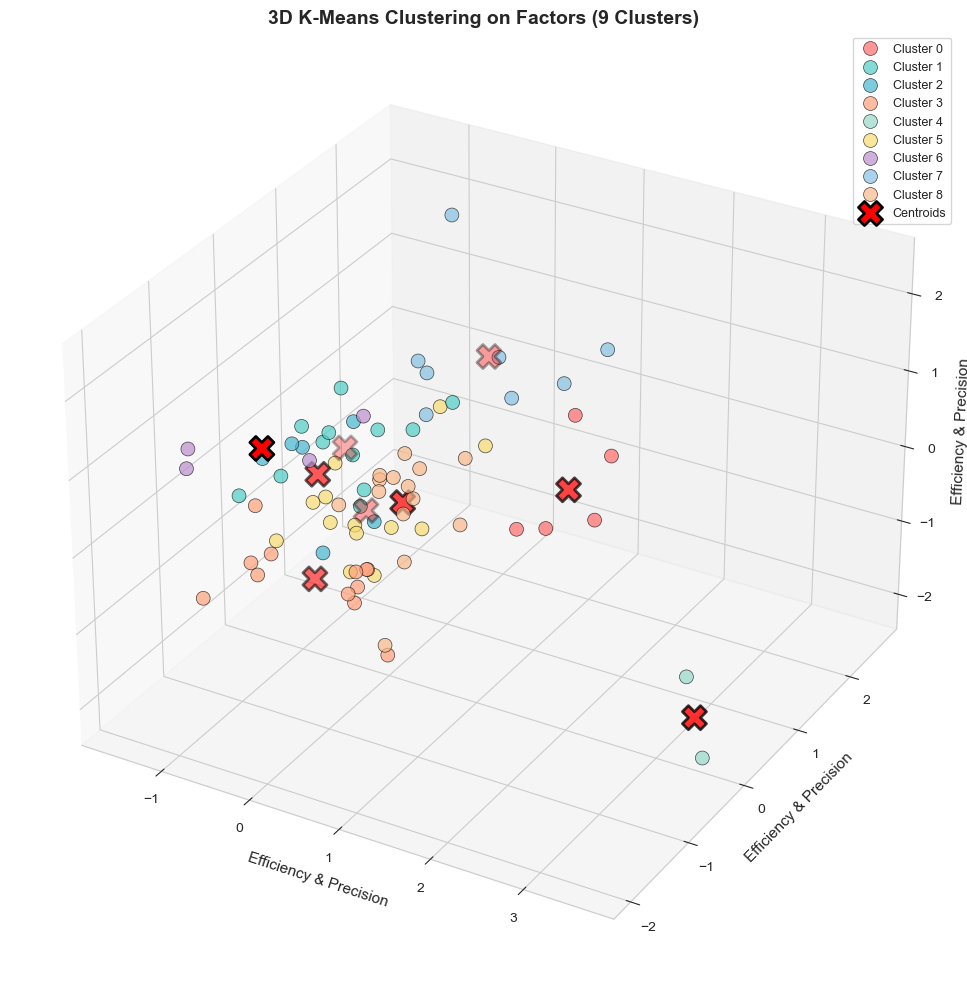

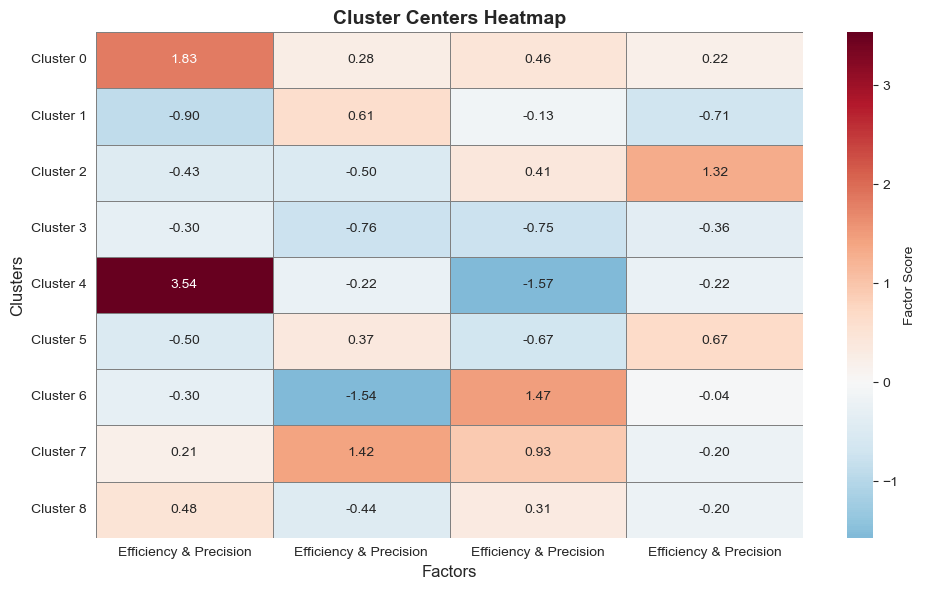


CLUSTER ANALYSIS COMPLETE
Successfully clustered 76 players into 9 clusters
Silhouette Score: 0.2461


In [17]:
# Create 3D visualization if we have at least 3 factors
if fa_optimal.n_components >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    for cluster_id in range(optimal_clusters):
        mask = cluster_labels == cluster_id
        ax.scatter(X_factors[mask, 0], X_factors[mask, 1], X_factors[mask, 2],
                  c=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id}',
                  s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Plot cluster centers
    ax.scatter(kmeans_optimal.cluster_centers_[:, 0], 
              kmeans_optimal.cluster_centers_[:, 1],
              kmeans_optimal.cluster_centers_[:, 2],
              c='red', marker='X', s=300, edgecolors='black', linewidth=2, 
              label='Centroids', zorder=5)
    
    ax.set_xlabel(factor_names.get('Factor 1', 'Factor 1'), fontsize=11)
    ax.set_ylabel(factor_names.get('Factor 2', 'Factor 2'), fontsize=11)
    ax.set_zlabel(factor_names.get('Factor 3', 'Factor 3'), fontsize=11)
    ax.set_title(f'3D K-Means Clustering on Factors ({optimal_clusters} Clusters)', 
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Create a heatmap of cluster centers
cluster_centers_df = pd.DataFrame(
    kmeans_optimal.cluster_centers_,
    columns=[factor_names.get(f'Factor {i+1}', f'Factor {i+1}') for i in range(fa_optimal.n_components)],
    index=[f'Cluster {i}' for i in range(optimal_clusters)]
)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_centers_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Factor Score'}, linewidths=0.5, linecolor='gray')
plt.title('Cluster Centers Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Clusters', fontsize=12)
plt.xlabel('Factors', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CLUSTER ANALYSIS COMPLETE")
print("="*70)
print(f"Successfully clustered {len(X_factors)} players into {optimal_clusters} clusters")
print(f"Silhouette Score: {silhouette_scores[optimal_clusters-2]:.4f}")
print("="*70)

## 10. Cluster Naming and Detailed Descriptions

In [18]:
# Analyze each cluster to name and describe them
cluster_names = {}
cluster_summaries = {}

print("="*70)
print("CLUSTER NAMING AND CHARACTERIZATION")
print("="*70)

for cluster_id in range(optimal_clusters):
    cluster_mask = cluster_labels == cluster_id
    cluster_center = kmeans_optimal.cluster_centers_[cluster_id]
    
    # Get factor values for this cluster
    factor_values = {}
    for factor_idx in range(fa_optimal.n_components):
        factor_name_key = f'Factor {factor_idx + 1}'
        factor_display_name = factor_names.get(factor_name_key, factor_name_key)
        factor_values[factor_display_name] = cluster_center[factor_idx]
    
    # Identify top strengths and weaknesses
    sorted_factors = sorted(factor_values.items(), key=lambda x: x[1], reverse=True)
    top_strength = sorted_factors[0]
    top_weakness = sorted_factors[-1]
    
    # Generate cluster name based on top characteristics
    top_factor_name = top_strength[0]
    
    # Create descriptive names
    if top_strength[1] > 0.3:  # Strong positive value
        if 'Offensive' in top_factor_name:
            cluster_names[cluster_id] = f"Elite Strikers"
        elif 'Playmaking' in top_factor_name:
            cluster_names[cluster_id] = f"Creative Forwards"
        elif 'Physical' in top_factor_name:
            cluster_names[cluster_id] = f"Physical Powerhouses"
        else:
            cluster_names[cluster_id] = f"Specialized Attackers"
    elif top_strength[1] > 0:  # Moderate positive
        cluster_names[cluster_id] = f"Balanced Performers"
    else:  # Negative values
        cluster_names[cluster_id] = f"Emerging Talents"
    
    # Build 3-sentence summary
    cluster_size = np.sum(cluster_mask)
    
    # Sentence 1: Overview
    overview = f"This cluster comprises {cluster_size} forwards with a {cluster_names[cluster_id].lower()} profile."
    
    # Sentence 2: Strengths
    if top_strength[1] > 0.2:
        strengths = f"The cluster excels in {top_strength[0].lower()} ({top_strength[1]:+.2f}), making these players particularly valuable in offensive and creative aspects of play."
    elif top_strength[1] > 0:
        strengths = f"The cluster shows moderate strength in {top_strength[0].lower()} ({top_strength[1]:+.2f}), providing reliable contributions across multiple areas."
    else:
        strengths = f"The cluster demonstrates balanced abilities across factors, with {top_strength[0].lower()} being the relatively strongest attribute ({top_strength[1]:+.2f})."
    
    # Sentence 3: Weaknesses
    if top_weakness[1] < -0.2:
        weaknesses = f"However, they show notable limitations in {top_weakness[0].lower()} ({top_weakness[1]:+.2f}), which may restrict their effectiveness in certain tactical situations."
    elif top_weakness[1] < 0:
        weaknesses = f"The cluster shows minor deficiencies in {top_weakness[0].lower()} ({top_weakness[1]:+.2f}), indicating room for development in this specific dimension."
    else:
        weaknesses = f"While versatile, they are less dominant in {top_weakness[0].lower()} ({top_weakness[1]:+.2f}), which could be a limiting factor against certain defensive setups."
    
    cluster_summaries[cluster_id] = f"{overview} {strengths} {weaknesses}"
    
    print(f"\n{'─'*70}")
    print(f"CLUSTER {cluster_id}: {cluster_names[cluster_id].upper()}")
    print(f"{'─'*70}")
    print(f"Size: {cluster_size} players")
    print(f"\nCluster Profile:")
    for factor_name, value in sorted_factors:
        direction = "↑" if value > 0 else "↓" if value < 0 else "→"
        print(f"  {direction} {factor_name}: {value:+.3f}")
    
    print(f"\nCluster Summary:")
    print(f"{cluster_summaries[cluster_id]}")

# Create comprehensive summary table
print("\n" + "="*70)
print("COMPREHENSIVE CLUSTER SUMMARY TABLE")
print("="*70)

summary_table_data = []
for cluster_id in range(optimal_clusters):
    cluster_mask = cluster_labels == cluster_id
    summary_table_data.append({
        'Cluster ID': cluster_id,
        'Cluster Name': cluster_names[cluster_id],
        'Size': np.sum(cluster_mask),
        'Summary': cluster_summaries[cluster_id]
    })

summary_table = pd.DataFrame(summary_table_data)
for idx, row in summary_table.iterrows():
    print(f"\n[Cluster {row['Cluster ID']}] {row['Cluster Name']} (n={row['Size']})")
    print(f"{row['Summary']}")

# Create detailed player assignments
print("\n" + "="*70)
print("DETAILED PLAYER ASSIGNMENTS BY CLUSTER")
print("="*70)

for cluster_id in range(optimal_clusters):
    cluster_players = factors_df_with_clusters[factors_df_with_clusters['Cluster'] == cluster_id].index.tolist()
    print(f"\n{cluster_names[cluster_id]} (Cluster {cluster_id}) - {len(cluster_players)} players:")
    print(f"  {', '.join(cluster_players)}")

CLUSTER NAMING AND CHARACTERIZATION

──────────────────────────────────────────────────────────────────────
CLUSTER 0: BALANCED PERFORMERS
──────────────────────────────────────────────────────────────────────
Size: 5 players

Cluster Profile:
  ↑ Efficiency & Precision: +0.218

Cluster Summary:
This cluster comprises 5 forwards with a balanced performers profile. The cluster excels in efficiency & precision (+0.22), making these players particularly valuable in offensive and creative aspects of play. While versatile, they are less dominant in efficiency & precision (+0.22), which could be a limiting factor against certain defensive setups.

──────────────────────────────────────────────────────────────────────
CLUSTER 1: EMERGING TALENTS
──────────────────────────────────────────────────────────────────────
Size: 12 players

Cluster Profile:
  ↓ Efficiency & Precision: -0.707

Cluster Summary:
This cluster comprises 12 forwards with a emerging talents profile. The cluster demonstrates

## 11. Individual Player Analysis: Pedro

In [24]:
# Helper function for article choice (define before using it)
def article_choice(word_first_letter):
    """Return 'a' or 'an' based on the first letter"""
    return 'an' if word_first_letter.lower() in 'aeiou' else 'a'

# Analyze Pedro specifically
player_search = "Pedro"

# Find the player (case-insensitive and handle special characters)
player_name = None
for idx in factors_df_with_clusters.index:
    if player_search.lower() in idx.lower():
        player_name = idx
        break

# If not found, show available players and try exact match
if player_name is None:
    print(f"Player '{player_search}' not found with substring matching.")
    print(f"\nAvailable players ({len(factors_df_with_clusters)} total):")
    print(factors_df_with_clusters.index.tolist())
    print(f"\nTrying exact match for '{player_search}'...")
    if player_search in factors_df_with_clusters.index:
        player_name = player_search

if player_name is not None:
    print("="*70)
    print(f"INDIVIDUAL PLAYER ANALYSIS: {player_name.upper()}")
    print("="*70)
    
    # Get player's factor scores and cluster
    player_factors = factors_df_with_clusters.loc[player_name]
    player_cluster_id = int(player_factors['Cluster'])
    player_cluster_name = cluster_names[player_cluster_id]
    
    print(f"\nCluster Assignment: {player_cluster_name} (Cluster {player_cluster_id})")
    
    # Get cluster center for comparison
    cluster_center = kmeans_optimal.cluster_centers_[player_cluster_id]
    overall_mean = kmeans_optimal.cluster_centers_.mean(axis=0)
    
    print("\n" + "─"*70)
    print("Factor Scores (Z-score normalized):")
    print("─"*70)
    
    strengths = []
    weaknesses = []
    
    for factor_idx in range(fa_optimal.n_components):
        # Use factor index directly to get the score
        player_score_val = float(X_factors[list(factors_df_with_clusters.index).index(player_name), factor_idx])
        cluster_score = float(cluster_center[factor_idx])
        
        # Get the display name from original factor_names dict
        factor_key = f'Factor {factor_idx + 1}'
        factor_display_name = factor_names.get(factor_key, factor_key)
        
        # Determine if above or below cluster average
        diff = player_score_val - cluster_score
        
        print(f"\n{factor_display_name}:")
        print(f"  {player_name}'s score: {player_score_val:+.3f}")
        print(f"  Cluster average: {cluster_score:+.3f}")
        print(f"  Difference from cluster: {diff:+.3f}")
        
        # Categorize as strength or weakness
        if player_score_val > 0.2:
            strengths.append((factor_display_name, player_score_val))
        elif player_score_val < -0.2:
            weaknesses.append((factor_display_name, player_score_val))
    
    # Generate 3-sentence summary
    print("\n" + "="*70)
    print("PLAYER SUMMARY: THREE-SENTENCE ANALYSIS")
    print("="*70)
    
    # Sentence 1: Strengths
    if strengths:
        strengths_sorted = sorted(strengths, key=lambda x: x[1], reverse=True)
        top_strength_name, top_strength_val = strengths_sorted[0]
        if len(strengths) > 1:
            second_strength_name, second_strength_val = strengths_sorted[1]
            sentence1 = f"{player_name} demonstrates strong performance in {top_strength_name.lower()} ({top_strength_val:+.2f}) and {second_strength_name.lower()} ({second_strength_val:+.2f}), making him a valuable contributor in the team's attacking dynamics."
        else:
            sentence1 = f"{player_name} excels particularly in {top_strength_name.lower()} ({top_strength_val:+.2f}), demonstrating elite proficiency in this critical forward attribute."
    else:
        # If no clear strengths, describe as balanced
        balanced_factors = []
        for factor_idx in range(fa_optimal.n_components):
            player_score_val = float(X_factors[list(factors_df_with_clusters.index).index(player_name), factor_idx])
            if -0.2 <= player_score_val <= 0.2:
                factor_key = f'Factor {factor_idx + 1}'
                factor_display_name = factor_names.get(factor_key, factor_key)
                balanced_factors.append((factor_display_name, player_score_val))
        
        if balanced_factors:
            top_factor = max(balanced_factors, key=lambda x: x[1])
            sentence1 = f"{player_name} demonstrates balanced overall performance with relatively consistent contributions across multiple areas, with {top_factor[0].lower()} being his most notable attribute ({top_factor[1]:+.2f})."
        else:
            sentence1 = f"{player_name} shows versatility across forward attributes with moderate contributions in multiple dimensions of play."
    
    # Sentence 2: Weaknesses/Average areas
    if weaknesses:
        weaknesses_sorted = sorted(weaknesses, key=lambda x: abs(x[1]), reverse=True)
        top_weakness_name, top_weakness_val = weaknesses_sorted[0]
        if len(weaknesses) > 1:
            second_weakness_name, second_weakness_val = weaknesses_sorted[1]
            sentence2 = f"However, {player_name} shows limitations in {top_weakness_name.lower()} ({top_weakness_val:+.2f}) and {second_weakness_name.lower()} ({second_weakness_val:+.2f}), which represent areas where he underperforms relative to elite forwards."
        else:
            sentence2 = f"Conversely, {player_name} exhibits a notable deficiency in {top_weakness_name.lower()} ({top_weakness_val:+.2f}), which may limit his effectiveness in certain tactical scenarios."
    else:
        # Identify areas where he's below cluster average
        below_cluster = []
        for factor_idx in range(fa_optimal.n_components):
            player_score_val = float(X_factors[list(factors_df_with_clusters.index).index(player_name), factor_idx])
            cluster_score = cluster_center[factor_idx]
            if player_score_val < cluster_score:
                factor_key = f'Factor {factor_idx + 1}'
                factor_display_name = factor_names.get(factor_key, factor_key)
                below_cluster.append((factor_display_name, player_score_val, cluster_score - player_score_val))
        
        if below_cluster:
            below_cluster_sorted = sorted(below_cluster, key=lambda x: x[2], reverse=True)
            top_below_name, top_below_val, gap = below_cluster_sorted[0]
            sentence2 = f"In comparison to his cluster peers, {player_name} trails in {top_below_name.lower()} ({top_below_val:+.2f}), indicating this is a relative weakness where improvement could enhance his effectiveness."
        else:
            sentence2 = f"Across all measured dimensions, {player_name} performs comparably to his cluster peers, with no significant deficiencies in any particular area."
    
    # Sentence 3: Conclusion
    conclusion_statement = f"Overall, {player_name} represents {article_choice(player_cluster_name[0])} {player_cluster_name.lower()} who plays a role consistent with {article_choice('e')} {player_cluster_name.lower()}'s profile within his peer group."
    
    # Alternative conclusion based on position in cluster
    if strengths and not weaknesses:
        conclusion_statement = f"Overall, {player_name} is {article_choice(player_cluster_name[0])} exemplary {player_cluster_name.lower()} with well-rounded strengths that make him a reliable offensive contributor."
    elif weaknesses and not strengths:
        conclusion_statement = f"Overall, {player_name} is {article_choice(player_cluster_name[0])} developing {player_cluster_name.lower()} with clear areas of focus for improvement to reach elite performance levels."
    else:
        conclusion_statement = f"Overall, {player_name} exemplifies the {player_cluster_name.lower()} archetype with both notable strengths and identifiable weaknesses that define his role within the forward classification."
    
    # Print the three-sentence summary
    print("\nSentence 1 (Strengths):")
    print(sentence1)
    print("\nSentence 2 (Weaknesses/Average):")
    print(sentence2)
    print("\nSentence 3 (Conclusion):")
    print(conclusion_statement)
    
    print("\n" + "="*70)
    print("COMPLETE THREE-SENTENCE SUMMARY")
    print("="*70)
    print(f"\n{sentence1} {sentence2} {conclusion_statement}")

else:
    print(f"\n❌ Player '{player_search}' not found in the dataset.")
    print(f"\n📋 Available players ({len(factors_df_with_clusters)} total):")
    for i, p in enumerate(sorted(factors_df_with_clusters.index.tolist()), 1):
        print(f"  {i}. {p}")

INDIVIDUAL PLAYER ANALYSIS: PEDRO

Cluster Assignment: Emerging Talents (Cluster 8)

──────────────────────────────────────────────────────────────────────
Factor Scores (Z-score normalized):
──────────────────────────────────────────────────────────────────────

Efficiency & Precision:
  Pedro's score: +0.637
  Cluster average: +0.477
  Difference from cluster: +0.159

Efficiency & Precision:
  Pedro's score: -0.655
  Cluster average: -0.439
  Difference from cluster: -0.216

Efficiency & Precision:
  Pedro's score: -0.266
  Cluster average: +0.308
  Difference from cluster: -0.574

Efficiency & Precision:
  Pedro's score: +0.032
  Cluster average: -0.195
  Difference from cluster: +0.228

PLAYER SUMMARY: THREE-SENTENCE ANALYSIS

Sentence 1 (Strengths):
Pedro excels particularly in efficiency & precision (+0.64), demonstrating elite proficiency in this critical forward attribute.

Sentence 2 (Weaknesses/Average):
However, Pedro shows limitations in efficiency & precision (-0.66) and e